# PUBG Update 42.1 Steam 리뷰 분석

## 분석 질문

**PUBG Update 42.1 전후 Steam 리뷰에서 사용자 반응과 주요 불만 이슈는 어떻게 변화했는가?**

이 노트북은 UTC 기준 14일씩의 두 기간을 비교합니다. 추천 비율과 플레이시간 특성을 확인하고, 비추천 리뷰의 키워드 기반 이슈 태그를 비교한 뒤, 원문 문맥 검증 결과를 함께 해석합니다. 공개 저장소에는 Steam 식별자와 리뷰 전문이 포함된 원본 리뷰 데이터가 없으며, 집계표와 익명화된 짧은 발췌만 사용합니다.


## 01. 라이브러리와 차트 한글 폰트 설정

현재 환경에서 사용 가능한 한글 폰트를 확인한 뒤 우선순위에 따라 적용합니다. 두 후보가 모두 없으면 matplotlib 기본 폰트로 계속 실행하고, 한글 글리프가 정상 표시되지 않을 수 있다는 경고를 출력합니다. 마이너스 기호가 깨지지 않도록 `axes.unicode_minus`도 설정합니다.


In [1]:
from pathlib import Path
import re
import sys
from decimal import Decimal, ROUND_HALF_UP

import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd
from IPython.display import display

font_names = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next(
    (candidate for candidate in ['Noto Sans KR', 'Malgun Gothic'] if candidate in font_names),
    None,
)
if korean_font is not None:
    plt.rcParams['font.family'] = korean_font
    print(f'적용 한글 폰트: {korean_font}')
else:
    print('경고: Noto Sans KR 또는 Malgun Gothic을 찾지 못했습니다. matplotlib 기본 폰트로 계속 실행하며 한글 글리프가 정상 표시되지 않을 수 있습니다.')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

def round_half_up(value, digits=2):
    unit = Decimal('1').scaleb(-digits)
    return float(Decimal(str(value)).quantize(unit, rounding=ROUND_HALF_UP))

print(f'Python: {sys.version.split()[0]}')
print(f'실행 파일: {sys.executable}')


적용 한글 폰트: Noto Sans KR
Python: 3.13.15
실행 파일: C:\Users\GdWoman\AppData\Local\Programs\Python\Python313\python.exe


## 02. 데이터 불러오기

이 저장소에는 집계 결과와 익명화된 짧은 발췌만 포함되어 있습니다. 이 노트북은 API를 호출하거나 데이터를 새로 수집하지 않습니다.


In [2]:
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'outputs').is_dir():
    REPO_ROOT = REPO_ROOT.parent
OUTPUTS = REPO_ROOT / 'outputs'
FIGURES = REPO_ROOT / 'figures'

summary = pd.read_csv(OUTPUTS / 'summary_statistics.csv')
validation = pd.read_csv(OUTPUTS / 'data_validation.csv')
issues = pd.read_csv(OUTPUTS / 'negative_issue_comparison.csv')
examples = pd.read_csv(OUTPUTS / 'representative_reviews_public.csv')

assert set(summary['period']) == {'Before', 'After'}
assert set(issues['issue']) == {
    'ranked_rp', 'matchmaking', 'cheating_fairness',
    'performance_technical', 'gameplay_balance'
}
print(f'집계표 {len(summary)}행, 검증표 {len(validation)}행, 이슈표 {len(issues)}행을 불러왔습니다.')


집계표 6행, 검증표 2행, 이슈표 5행을 불러왔습니다.


## 03. 데이터 검증

업데이트 이전(PRE)은 `[2026-06-03 08:30, 2026-06-17 08:30)`, 업데이트 이후(POST)는 `[2026-06-17 08:30, 2026-07-01 08:30)`의 UTC 반열린 구간입니다. 기준 시각은 `scheduled_maintenance_end_proxy`입니다.

원본 검증에서 중복 Recommendation ID는 없었습니다. 빈 리뷰 텍스트는 기초 집계에는 유지하고 텍스트 분석에서는 제외했습니다.


In [3]:
validation_view = validation[[
    'period', 'rows', 'duplicate_ids', 'null_review',
    'blank_review_including_null', 'oldest_utc', 'newest_utc'
]].copy()
validation_view['period'] = validation_view['period'].map({'Before': 'PRE', 'After': 'POST'})

assert validation.set_index('period').loc['Before', 'rows'] == 667
assert validation.set_index('period').loc['After', 'rows'] == 850
assert validation['duplicate_ids'].eq(0).all()
display(validation_view)
print('검증 완료: PRE 667건, POST 850건, 중복 Recommendation ID 0건')


,period,rows,duplicate_ids,null_review,blank_review_including_null,oldest_utc,newest_utc
0,PRE,667,0,0,0,2026-06-03 11:04:15+00:00,2026-06-17 08:22:07+00:00
1,POST,850,0,3,4,2026-06-17 08:44:42+00:00,2026-07-01 08:26:56+00:00


검증 완료: PRE 667건, POST 850건, 중복 Recommendation ID 0건


## 04. 기본 비교

PRE와 POST는 동일 사용자를 추적한 cohort가 아니라 서로 다른 시점의 리뷰 표본입니다. 따라서 플레이시간 차이는 리뷰 작성자 구성의 관찰 결과이며, 업데이트가 플레이시간을 변화시켰다는 의미로 해석하지 않습니다.


In [4]:
basic = summary.loc[summary['recommendation_group'].eq('All'), [
    'period', 'review_count', 'recommended_count', 'not_recommended_count',
    'recommendation_rate', 'playtime_median_hours', 'review_length_median',
    'helpful_vote_median'
]].copy()
basic['recommendation_rate'] = basic['recommendation_rate'].mul(100).round(2)
basic['playtime_median_hours'] = basic['playtime_median_hours'].map(round_half_up)
basic['period'] = basic['period'].map({'Before': 'PRE', 'After': 'POST'})
basic = basic.rename(columns={
    'period': '기간', 'review_count': '리뷰 수', 'recommended_count': '추천 리뷰 수',
    'not_recommended_count': '비추천 리뷰 수', 'recommendation_rate': '추천 비율 (%)',
    'playtime_median_hours': '플레이시간 중앙값 (시간)',
    'review_length_median': '리뷰 길이 중앙값 (자)',
    'helpful_vote_median': 'Helpful vote 중앙값'
})
display(basic.style.format({'추천 비율 (%)': '{:.2f}', '플레이시간 중앙값 (시간)': '{:.2f}', '리뷰 길이 중앙값 (자)': '{:.0f}', 'Helpful vote 중앙값': '{:.0f}'}))
print('추천 비율 변화: -0.21%p | 플레이시간 중앙값: 50.37시간 → 89.23시간')


,기간,리뷰 수,추천 리뷰 수,비추천 리뷰 수,추천 비율 (%),플레이시간 중앙값 (시간),리뷰 길이 중앙값 (자),Helpful vote 중앙값
0,PRE,667,524,143,78.56,50.37,19,0
3,POST,850,666,184,78.35,89.23,15,0


추천 비율 변화: -0.21%p | 플레이시간 중앙값: 50.37시간 → 89.23시간


## 05. 이슈 태깅 기준

이슈 비율은 각 기간의 전체 비추천 리뷰를 분모로 계산했습니다(PRE 143건, POST 184건). 하나의 리뷰에 여러 태그가 붙을 수 있는 multi-label 방식입니다. 아래 사전과 단어 경계 정규식은 기존 분석에서 사용한 기준을 그대로 유지합니다.


In [5]:
issue_keywords = {
    'ranked_rp': ['rank', 'ranked', 'rp', 'rating', 'tier', 'point', 'points'],
    'matchmaking': ['matchmaking', 'match making', 'queue', 'teammate', 'teammates'],
    'cheating_fairness': ['cheater', 'cheaters', 'cheating', 'cheat', 'hack', 'hacker', 'hackers'],
    'performance_technical': ['lag', 'fps', 'crash', 'crashing', 'server', 'servers', 'performance', 'optimization'],
    'gameplay_balance': ['balance', 'balanced', 'weapon', 'weapons', 'gun', 'guns', 'damage', 'gameplay'],
}

def tag_negative_reviews(reviews: pd.DataFrame) -> pd.DataFrame:
    # 기존 multi-label, 단어 경계 태깅 로직. 공개 저장소에는 리뷰 전문이 없어 실행하지 않습니다.
    tagged = reviews.copy()
    for issue, keywords in issue_keywords.items():
        pattern = r'|'.join(r'\b' + r'\s+'.join(map(re.escape, word.split())) + r'\b' for word in keywords)
        tagged[issue] = tagged['review'].fillna('').str.contains(pattern, case=False, regex=True)
    return tagged

dictionary_view = pd.DataFrame({
    '이슈 태그': list(issue_keywords),
    '키워드': [', '.join(words) for words in issue_keywords.values()]
})
display(dictionary_view)


,이슈 태그,키워드
0,ranked_rp,"rank, ranked, rp, rating, tier, point, points"
1,matchmaking,"matchmaking, match making, queue, teammate, te..."
2,cheating_fairness,"cheater, cheaters, cheating, cheat, hack, hack..."
3,performance_technical,"lag, fps, crash, crashing, server, servers, pe..."
4,gameplay_balance,"balance, balanced, weapon, weapons, gun, guns,..."


## 06. PRE와 POST 이슈 비교

변화량은 상대 증감률이 아니라 **퍼센트포인트(%p)** 로 계산했습니다. 즉, `POST 이슈 비율 - PRE 이슈 비율`입니다.


In [6]:
issue_labels_ko = {
    'ranked_rp': 'Ranked / RP',
    'matchmaking': '매치메이킹',
    'cheating_fairness': '치팅 / 공정성',
    'performance_technical': '성능 / 기술',
    'gameplay_balance': '게임플레이 / 밸런스',
}
issue_view = issues[[
    'issue', 'Before_count', 'Before_negative_denominator', 'Before_mention_pct',
    'After_count', 'After_negative_denominator', 'After_mention_pct', 'change_pp'
]].copy()
issue_view['issue'] = issue_view['issue'].map(issue_labels_ko)
for column in ['Before_mention_pct', 'After_mention_pct', 'change_pp']:
    issue_view[column] = issue_view[column].round(2)
issue_view = issue_view.rename(columns={
    'issue': '이슈', 'Before_count': 'PRE 언급 수',
    'Before_negative_denominator': 'PRE 비추천 분모', 'Before_mention_pct': 'PRE 비율 (%)',
    'After_count': 'POST 언급 수', 'After_negative_denominator': 'POST 비추천 분모',
    'After_mention_pct': 'POST 비율 (%)', 'change_pp': '변화 (%p)'
})
display(issue_view.style.format({'PRE 비율 (%)': '{:.2f}', 'POST 비율 (%)': '{:.2f}', '변화 (%p)': '{:+.2f}'}))
print('이슈 비교표는 원본 집계 CSV를 수정하지 않고 표시용 열 이름만 한글화합니다.')


,이슈,PRE 언급 수,PRE 비추천 분모,PRE 비율 (%),POST 언급 수,POST 비추천 분모,POST 비율 (%),변화 (%p)
0,Ranked / RP,9,143,6.29,7,184,3.80,-2.49
1,매치메이킹,7,143,4.90,4,184,2.17,-2.72
2,치팅 / 공정성,30,143,20.98,33,184,17.93,-3.04
3,성능 / 기술,10,143,6.99,14,184,7.61,+0.62
4,게임플레이 / 밸런스,10,143,6.99,10,184,5.43,-1.56


이슈 비교표는 원본 집계 CSV를 수정하지 않고 표시용 열 이름만 한글화합니다.


## 07. 차트 저장

아래 차트는 공개된 집계 CSV로 다시 생성합니다. 모든 제목, 축, 범례는 한글로 표시하며, 수치와 계산 기준은 기존 분석 결과를 그대로 사용합니다.


findfont: Failed to find font weight normal, now using 100.


findfont: Failed to find font weight normal, now using 100.


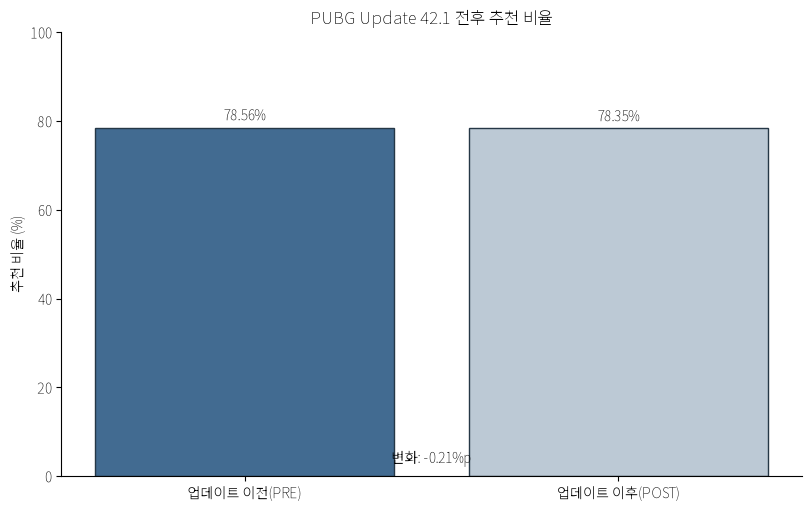

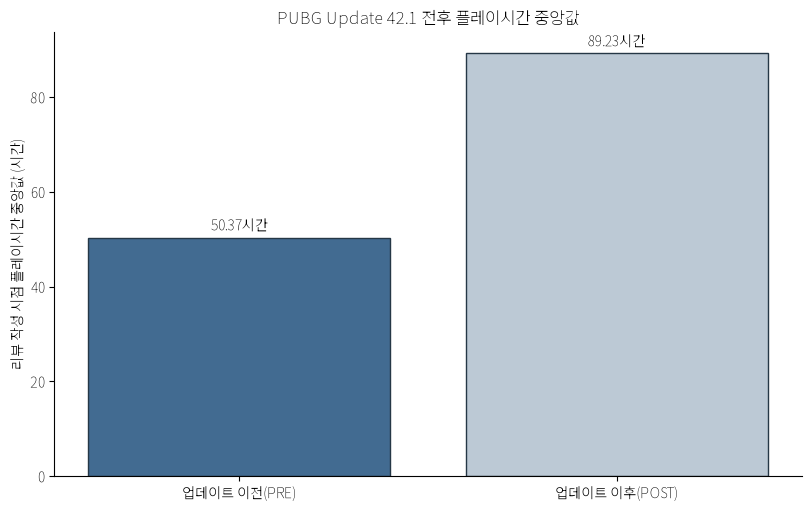

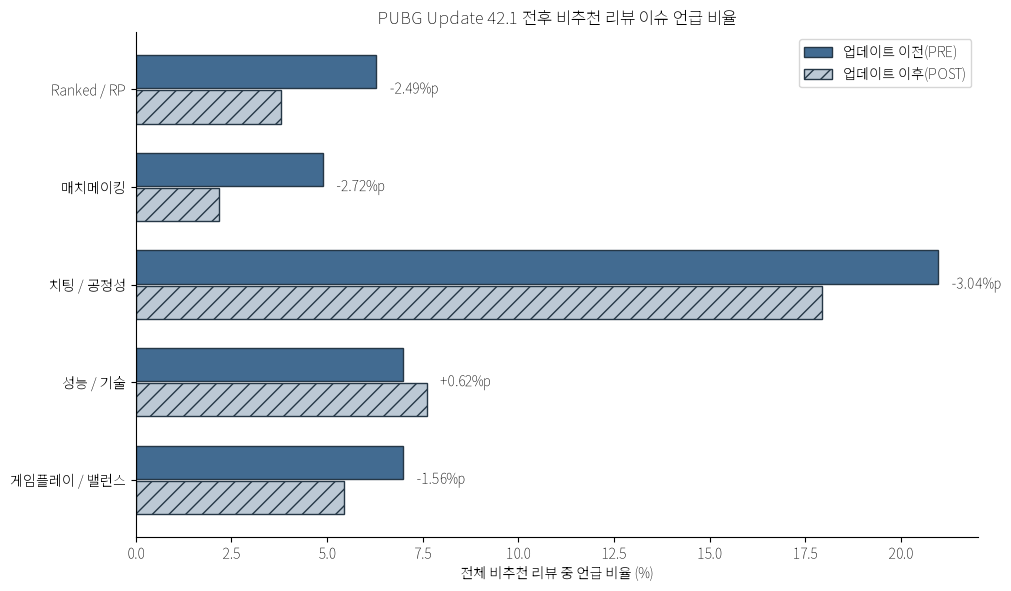

차트 저장 완료: recommendation_rate.png, median_playtime.png, negative_issue_change.png


In [7]:
period_labels = ['업데이트 이전(PRE)', '업데이트 이후(POST)']
all_summary = summary.loc[summary['recommendation_group'].eq('All')].set_index('period').loc[['Before', 'After']]
colors = ['#426b91', '#bcc9d5']
FIGURES.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
rates = all_summary['recommendation_rate'].mul(100)
bars = ax.bar(period_labels, rates, color=colors, edgecolor='#253746')
ax.bar_label(bars, labels=[f'{value:.2f}%' for value in rates], padding=4)
ax.set_ylim(0, 100)
ax.set_ylabel('추천 비율 (%)')
ax.set_title('PUBG Update 42.1 전후 추천 비율')
ax.text(0.5, 0.03, '변화: -0.21%p', transform=ax.transAxes, ha='center')
fig.savefig(FIGURES / 'recommendation_rate.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5), layout='constrained')
medians = all_summary['playtime_median_hours']
bars = ax.bar(period_labels, medians, color=colors, edgecolor='#253746')
ax.bar_label(bars, labels=[f'{round_half_up(value):.2f}시간' for value in medians], padding=4)
ax.set_ylabel('리뷰 작성 시점 플레이시간 중앙값 (시간)')
ax.set_title('PUBG Update 42.1 전후 플레이시간 중앙값')
fig.savefig(FIGURES / 'median_playtime.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(10, 5.8), layout='constrained')
issue_plot = issues.copy()
y = range(len(issue_plot))
before = issue_plot['Before_mention_pct']
after = issue_plot['After_mention_pct']
ax.barh([value - 0.18 for value in y], before, height=0.34, label='업데이트 이전(PRE)', color=colors[0], edgecolor='#253746')
ax.barh([value + 0.18 for value in y], after, height=0.34, label='업데이트 이후(POST)', color=colors[1], edgecolor='#253746', hatch='//')
ax.set_yticks(list(y), [issue_labels_ko[value] for value in issue_plot['issue']])
ax.set_xlabel('전체 비추천 리뷰 중 언급 비율 (%)')
ax.set_title('PUBG Update 42.1 전후 비추천 리뷰 이슈 언급 비율')
ax.legend()
for index, row in issue_plot.iterrows():
    ax.text(max(row['Before_mention_pct'], row['After_mention_pct']) + 0.35, index, f"{row['change_pp']:+.2f}%p", va='center')
ax.invert_yaxis()
fig.savefig(FIGURES / 'negative_issue_change.png', dpi=160, bbox_inches='tight')
display(fig)
plt.close(fig)

print('차트 저장 완료: recommendation_rate.png, median_playtime.png, negative_issue_change.png')


## 08. 원문 문맥 검증

키워드 탐지는 후보를 찾는 단계일 뿐 Update 42.1의 RP 계산 변경을 직접 언급했다는 증거는 아닙니다. 아래 표는 Steam 사용자 식별자와 리뷰 전문을 제외한 공개용 짧은 발췌입니다. 기존 세부 검증에서는 Ranked/RP 키워드 후보 16건(PRE 9건, POST 7건) 중 RP 계산 변경을 구체적으로 언급한 리뷰가 PRE와 POST 모두 0건이었습니다.


In [8]:
display(examples)
print('문맥 검증 결과: RP 계산 변경을 구체적으로 언급한 리뷰는 PRE 0건, POST 0건입니다.')


,period,recommended,issue_tag,short_excerpt
0,PRE,False,Matchmaking,Almost every match puts me against level 300-4...
1,POST,False,Matchmaking,Garbage matchmaking and balancing: a new begin...
2,PRE,False,Cheating / fairness,A reviewer described an anti-cheat-triggered b...
3,POST,False,Cheating / fairness,Too many years of not doing anything about the...
4,PRE,False,Performance / technical,A reviewer said that patches brought no meanin...
5,POST,False,Performance / technical,"The lobby runs smoothly, but lag begins after ..."
6,PRE,False,Ranked / RP keyword candidate,A tier 1 player described being repeatedly mat...
7,POST,False,Ranked / RP keyword candidate,No point in playing if cheaters can return aft...


문맥 검증 결과: RP 계산 변경을 구체적으로 언급한 리뷰는 PRE 0건, POST 0건입니다.


## 09. 결론

- 추천 비율은 PRE 78.56%에서 POST 78.35%로 **-0.21%p** 변해, 전체 추천 반응의 뚜렷한 변화는 관찰되지 않았습니다.
- Ranked/RP, 매치메이킹, 치팅/공정성 이슈 비율은 패치 이후 감소했고, 성능/기술 언급은 **+0.62%p** 소폭 증가했습니다.
- 리뷰 작성 시점 플레이시간 중앙값은 50.37시간에서 89.23시간으로 높았지만, 동일 사용자 비교가 아니므로 업데이트 효과로 해석하지 않습니다.
- Ranked/RP 키워드 비율은 6.29%에서 3.80%로 감소했으나, RP 계산 변경을 직접 평가한 문맥 근거는 충분하지 않았습니다.

따라서 이 결과는 Steam 리뷰 표본에서 관찰된 변화이며, Update 42.1이 특정 불만을 감소시켰다는 인과적 증거는 아닙니다.
